In [1]:
import pandas as pd    
import json
import matplotlib.pyplot as plt
import sys
import os
import importlib
import subprocess

sys.path.append('../utils/')
from vllm_server import *
from notebook_utils import *
import vllm_server
import notebook_utils

importlib.reload(vllm_server)
importlib.reload(notebook_utils)


<module 'notebook_utils' from '/home/p316289/Desktop/work/dl-mig-contention-aware-system/experiments/notebooks/../utils/notebook_utils.py'>

In [2]:
EXP_RESULTS_PATH="../results/"
EXP_NAME="vllm_pcie_bw_sweep"
EXP_CPU_OFFLOAD_FLAG="_cpuoffload-on"
EXP_ARTIFACTS_TAR="artifacts.tar.gz" # Not used in this experiment
EXP_METADATA="run_metadata.json"
EXP_METRICS="system_metrics.tar.gz"
SCHEDULER_LOGS="server_results.tar.gz"

In [3]:
# Work on Latest Exp, unless stated otherwise
EXP_PATH_PRE=EXP_RESULTS_PATH + EXP_NAME + EXP_CPU_OFFLOAD_FLAG

latest_exp_dir = get_latest_experiment_dir(EXP_RESULTS_PATH, EXP_PATH_PRE)

if latest_exp_dir:
    print(f"Latest experiment directory: {latest_exp_dir}")
else:
    print("No matching experiment directory found.")

Latest experiment directory: ../results/../results/vllm_pcie_bw_sweep_cpuoffload-on_20261006T120648


In [4]:
# Print experiment metadata
with open(f"{latest_exp_dir}/{EXP_METADATA}", 'r') as f:
    metadata = json.load(f)
    print(json.dumps(metadata, indent=2))

{
  "burst_ticks": 0,
  "continue_on_failure": false,
  "cpu_offload_by_model": {
    "Qwen/Qwen2.5-1.5B-Instruct": "0.2",
    "Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8": "0.2",
    "RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16": "0.2",
    "RedHatAI/gemma-2-2b-it-quantized.w4a16": "0.1"
  },
  "cpu_offload_enabled": true,
  "gb_rate_values": [
    1,
    2,
    4,
    8,
    16,
    32
  ],
  "git_commit": "0257fc5adbc3f1ed94cd7e94c76c2e9e70317fdb",
  "include_baseline": true,
  "libcuda_log_level": "2",
  "models": [
    "RedHatAI/gemma-2-2b-it-quantized.w4a16",
    "RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16",
    "Qwen/Qwen2.5-1.5B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8"
  ],
  "rate_control_worker_id": 1,
  "request_count": [
    "200"
  ],
  "request_rate": [
    "10"
  ],
  "run_id": "vllm_pcie_bw_sweep_cpuoffload-on_20261006T120648",
  "timestamp": "20261006T120648",
  "vllm_extra_args": [
    "--tensor-parallel-size",
    "1",
    "--max-model-len",
    "1024",
    "

In [5]:
# Extract artifacts and system metrics
data_dict = {}
for rps in metadata['request_rate']:
    for nrq in metadata['request_count']:
        for model in metadata['models']:
            # Extract Baseline Data
            data_dict[model] = {}
            model_path_name = model.replace('/', '_')
            dest = f"/tmp/{str(latest_exp_dir).split('/')[-1]}/{model_path_name}/baseline"
            data_dict[model]['baseline'] = {}
            if not os.path.exists(dest):
                os.makedirs(dest, exist_ok=True)
            subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{model_path_name}/baseline/{EXP_ARTIFACTS_TAR}", "-C", dest])
            subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{model_path_name}/baseline/{EXP_METRICS}", "-C", dest])
            subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{model_path_name}/baseline/{SCHEDULER_LOGS}", "-C", dest])
            data_dict[model]['baseline'][EXP_ARTIFACTS_TAR] = f"{dest}/{EXP_ARTIFACTS_TAR}"
            data_dict[model]['baseline'][EXP_METRICS] = f"{dest}/baseline__{model_path_name}_rps{rps}_n{nrq}.csv"

            # Extract other settings
            for gb_settings in metadata['gb_rate_values']:
                data_dict[model][gb_settings] = {}
                dest = f"/tmp/{str(latest_exp_dir).split('/')[-1]}/{model_path_name}/gb_rate-{gb_settings}"
                if not os.path.exists(dest):
                    os.makedirs(dest, exist_ok=True)
                subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{model_path_name}/gb_rate-{gb_settings}/{EXP_ARTIFACTS_TAR}", "-C", dest])
                subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{model_path_name}/gb_rate-{gb_settings}/{EXP_METRICS}", "-C", dest])
                subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{model_path_name}/gb_rate-{gb_settings}/{SCHEDULER_LOGS}", "-C", dest])
                data_dict[model][gb_settings][EXP_ARTIFACTS_TAR] = f"{dest}/{EXP_ARTIFACTS_TAR}"
                data_dict[model][gb_settings][EXP_METRICS] = f"{dest}/gb_rate-{gb_settings}__{model_path_name}_rps{rps}_n{nrq}.csv"
                data_dict[model][gb_settings][SCHEDULER_LOGS] = f"{dest}/scheduler.csv"

<Axes: xlabel='tick'>

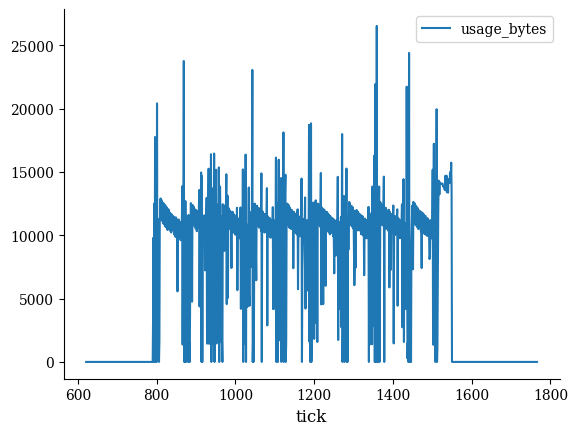

In [6]:
df = pd.read_csv(data_dict["RedHatAI/gemma-2-2b-it-quantized.w4a16"][1][SCHEDULER_LOGS])
df = df[df["phase"] == "limit"]
df.plot(x="tick", y="usage_bytes", kind="line")

In [40]:
df.loc[df["usage_bytes"] > 0, "tick"].min(), df.loc[df["usage_bytes"] > 0, "tick"].max()

(np.int64(764), np.int64(1313))

<Axes: xlabel='tick'>

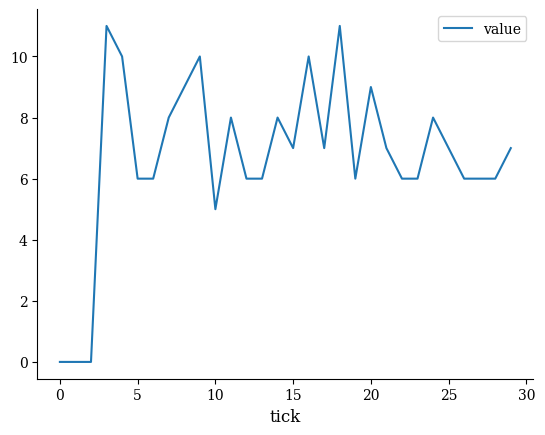

In [39]:
df_pcie = pd.read_csv(data_dict["Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8"][1][EXP_METRICS])
df_pcie = df_pcie[df_pcie["metric"] == "DCGM_FI_PROF_PCIE_RX_BYTES"]
df_pcie["value"] = df_pcie["value"].astype(float) // (1024 * 1024 * 1024)
df_pcie["tick"] = df_pcie.reset_index().index
df_pcie.plot(x="tick", y="value", kind="line")


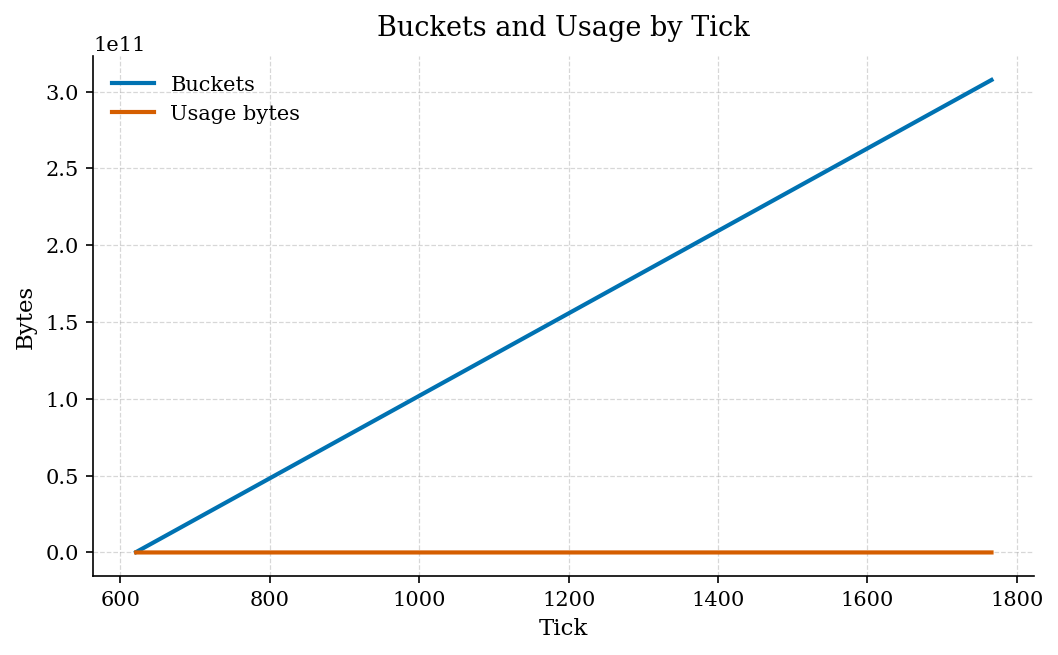

In [5]:
plot_df = df.sort_values("tick")

fig, ax = plt.subplots(figsize=(7.2, 4.5), dpi=150)

ax.plot(
    plot_df["tick"], plot_df["buckets"],
    color="#0072B2", linewidth=2, label="Buckets"
)
ax.plot(
    plot_df["tick"], plot_df["usage_bytes"].cumsum(),
    color="#D55E00", linewidth=2, label="Usage bytes"
)

ax.set_xlabel("Tick", fontsize=11)
ax.set_ylabel("Bytes", fontsize=11)
ax.set_title("Buckets and Usage by Tick", fontsize=13, pad=10)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, fontsize=10)
ax.tick_params(labelsize=10)

fig.tight_layout()
plt.show()